# Week 5b.2: Support Agent with Reflexive RAG

The previous reflexive RAG loop is a standalone graph. 

It knows nothing about orders, escalation, or the conversation the customer is having.

We'll integrate it into our support agent graph.

In [152]:
from dotenv import load_dotenv
import os

load_dotenv()
assert os.getenv("GOOGLE_API_KEY"), "No GOOGLE_API_KEY found."
print("API key loaded")

API key loaded


## 0. Model Setup

Execute one of the following to define the model.

In [153]:
from langchain_ollama import ChatOllama

model = ChatOllama(model="qwen3.5:4b", reasoning=False)

In [ ]:
from langchain.chat_models import init_chat_model

model = init_chat_model(model="gpt-4.1-mini")

In [154]:
from langchain_google_genai import ChatGoogleGenerativeAI

model = ChatGoogleGenerativeAI(model="gemini-3.5-flash-lite")

## 2. The revised loop

We'll build the same graph as the previous notebook with no `generate` node.

The support agent already writes the answer. It has the system prompt, the other tools, and the conversation. If the inner loop also wrote prose, two models would be writing to the same customer.


In [155]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings

embeddings = GoogleGenerativeAIEmbeddings(model="models/gemini-embedding-001")

In [81]:
from langchain_ollama import OllamaEmbeddings

embeddings = OllamaEmbeddings(model="qwen3-embedding:0.6b")

In [ ]:
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings(
    model="liquid/lfm-2.5-embedding-350m:free",
    base_url="https://openrouter.ai/api/v1",
    api_key=os.environ["OPENROUTER_API_KEY"],
    check_embedding_ctx_length=False,
)

In [ ]:
from langchain_nvidia_ai_endpoints import NVIDIAEmbeddings

embeddings = NVIDIAEmbeddings(model="nvidia/nemotron-3-embed-1b")

In [156]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.vectorstores import InMemoryVectorStore

policy = open("husky_policy.md").read()
chunks = RecursiveCharacterTextSplitter(chunk_size=400, chunk_overlap=0).split_text(policy)
store = InMemoryVectorStore.from_texts(chunks, embeddings)

print(f"{len(chunks)} chunks indexed")

6 chunks indexed


In [157]:
from pydantic import BaseModel, Field


class Grade(BaseModel):
    """Grade whether the retrieved passages answer the customer's question."""

    reasoning: str = Field(
        description="Name the rule that would settle this question, then say "
                    "whether it appears in the passages above")
    sufficient: bool = Field(
        description="True only if the passages contain every rule needed to answer")
    missing: str = Field(
        description="If not sufficient, what is missing, in a few words")


grader = model.with_structured_output(Grade)

GRADE_PROMPT = """A customer asked: {question}

Retrieved policy passages:

{context}

Do these passages contain the policy rules needed to answer this question?
If a rule is referred to but not stated here, it is missing.

Judge the passages, not the customer. The customer may not have mentioned every
detail about their situation, and that is not something retrieval can fix. If the
rules are here and the answer depends on a detail only the customer can supply,
the passages are sufficient."""

REWRITE_PROMPT = """A search over a policy document did not return what was needed.

Customer question: {question}
Search just tried: {query}
What is still missing: {missing}

Write a different question to search with, aimed at the part that is missing.
Ask it as a plain question in a full sentence. Do not write a list of keywords.
Reply with the question only."""

### Revising the RetrievalState class
The state no longer needs an `answer` field. Nothing in the retrieval loop will answer anything.

`retrieve` also falls back to `question` when `query` is empty, so the tool only has to pass the question along.

In [158]:
import operator
from typing import Annotated, Literal, TypedDict


class RetrievalState(TypedDict):
    question: str
    query: str
    documents: Annotated[list, operator.add]
    missing: str
    grade: str
    attempts: int

In [159]:
MAX_ATTEMPTS = 3
K = 2


def retrieve(state: RetrievalState) -> dict:
    query = state.get("query") or state["question"]
    existing_docs = set(state.get("documents") or [])
    new_docs = [h.page_content for h in store.similarity_search(query, k=K)
             if h.page_content not in existing_docs]
    return {"documents": new_docs, "query": query,
            "attempts": state.get("attempts", 0) + 1}


def grade_documents(state: RetrievalState) -> dict:
    augmented_query = GRADE_PROMPT.format(question=state["question"], 
                                context="\n\n".join(state["documents"]))
    verdict = grader.invoke(augmented_query)
    return {"grade": "sufficient" if verdict.sufficient else "insufficient",
            "missing": verdict.missing}


def rewrite_query(state: RetrievalState) -> dict:
    revised_prompt = REWRITE_PROMPT.format(question=state["question"], 
                                            query=state["query"],
                                            missing=state["missing"])
    
    new_query = model.invoke(revised_prompt).text.strip()
    return {"query": new_query}


def decide(state: RetrievalState) -> Literal["rewrite_query", "__end__"]:
    if state["grade"] == "sufficient":
        return "__end__"
    if state["attempts"] >= MAX_ATTEMPTS:
        return "__end__"
    return "rewrite_query"

The graph ends where `generate` used to be. 

The result contains:
- Whatever is in `documents` 
- `grade` when the graph stops 

`retrieve` also writes `query` back, so every checkpoint records the wording it actually searched with.

In [160]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver

retrieval = StateGraph(RetrievalState)
retrieval.add_node("retrieve", retrieve)
retrieval.add_node("grade_documents", grade_documents)
retrieval.add_node("rewrite_query", rewrite_query)

retrieval.add_edge(START, "retrieve")
retrieval.add_edge("retrieve", "grade_documents")
retrieval.add_conditional_edges("grade_documents", decide)
retrieval.add_edge("rewrite_query", "retrieve")

policy_search = retrieval.compile(checkpointer=InMemorySaver())

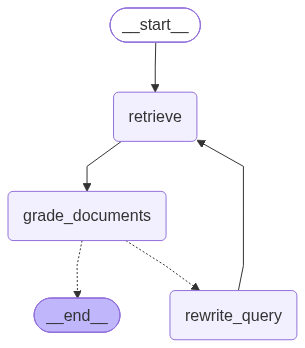

In [161]:
from IPython.display import Image, display

display(Image(policy_search.get_graph().draw_mermaid_png()))

## 3. A compiled graph inside a tool

We can call a compiled graph inside a tool
- `policy_search` is a compiled graph, and `.invoke()` on it is the same call we make at the top level.


On a good search the tool returns passages, as naive RAG did. 

When the loop gave up, it returns the passages **and a note about what it could not confirm**.

That note is a template, like the prompts above. Its exact wording matters more than anything else in this notebook, and section 6 is about why.

In [162]:
import uuid

from langchain.tools import tool

GAP_NOTE = """NOTE: after {attempts} searches the policy search did not find a rule
that settles this question ({missing}). The search coming up empty is not proof the
policy is silent, and a silent policy would not mean no. Do not tell the customer
that Husky Tech does or does not do this, and do not fill the gap from memory. This
is a question the tools cannot resolve. Mention this to the user by saying the policy
doesn't include information about the question."""


# Each search runs on its own thread. We keep the last one so we can look at
# what the loop did after the fact.
last_search = {}


@tool
def search_policy(question: str) -> str:
    """Search the Husky Tech written policy and return the passages most relevant
    to a question. Use this for any question about returns, shipping, warranty or
    support hours. Returns policy text, not an answer: read it and decide."""
    last_search["config"] = {"configurable": {"thread_id": uuid.uuid4().hex}}
    
    result = policy_search.invoke({"question": question}, last_search["config"])
    passages = "\n\n---\n\n".join(d.strip() for d in result["documents"])

    if result["grade"] == "sufficient":
        return passages

    note = GAP_NOTE.format(attempts=result["attempts"],
                           missing=result["missing"][:120])
    return passages + "\n\n---\n\n" + note

## 4. The same ReAct agent loop

Compare this agent with the one in W05a.1. It uses the same state, same nodes, same edges, and same tool list.

Only change: what `search_policy` does when called

In [163]:
from support_tools import look_up_order, check_return_eligibility, escalate_to_human, SYSTEM_PROMPT
from langchain.messages import SystemMessage, HumanMessage
from langgraph.graph import MessagesState
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import InMemorySaver

sys_msg = SystemMessage(content=SYSTEM_PROMPT)
TOOLS = [look_up_order, check_return_eligibility, search_policy, escalate_to_human]
model_with_tools = model.bind_tools(TOOLS)


def assistant(state: MessagesState) -> dict:
    return {"messages": [model_with_tools.invoke([sys_msg] + state["messages"])]}


builder = StateGraph(MessagesState)
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(TOOLS))
builder.add_edge(START, "assistant")
builder.add_conditional_edges("assistant", tools_condition)
builder.add_edge("tools", "assistant")

support_agent = builder.compile(checkpointer=InMemorySaver())

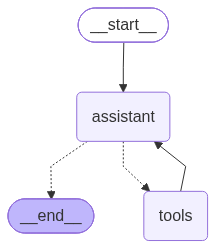

In [164]:
display(Image(support_agent.get_graph().draw_mermaid_png()))

<img src="figures/nested_loop.png" width="860">

Two loops now, one inside the other. 
- The outer one decides **when to search**, which is the model choosing to call a tool. 
- The inner one decides **when it has searched enough**, which is the grader.



## 5. Test

Let's try the spill question from the previous notebook.

In [165]:
from langchain.messages import HumanMessage

config = {"configurable": {"thread_id": "3"}}
question = "I spilled water on my keyboard and it stopped working. Can I get a replacement under warranty?"

result = support_agent.invoke({"messages": [HumanMessage(content=question)]}, config)
print(result["messages"][-1].text)

I'm sorry to hear about your keyboard, but liquid damage is not covered under the Husky Tech one-year manufacturer warranty (which only covers defects in materials and workmanship). 

If you have any other questions about our products, orders, or policies, please let me know!


It gets it right, and we did not touch the agent to make that happen.

Look at what the tool handed back:

In [166]:
from langchain.messages import ToolMessage

for m in result["messages"]:
    if isinstance(m, ToolMessage) and m.name == "search_policy":
        print(m.content)

Approved warranty claims are fulfilled with a replacement unit of the same
model, or an equivalent model if the original is discontinued. Replacement
units ship within 3 business days of a claim being approved.

## 4. Support hours

Support is available Monday through Friday, 9am to 6pm Eastern Time. Messages
received outside those hours are answered the next business day.

---

Orders placed after 2pm ET ship the following business day. Orders placed on a
weekend ship on the next Monday.

## 3. Warranty

All Husky Tech electronics include a one-year manufacturer warranty covering
defects in materials and workmanship. The warranty does not cover accidental
damage, liquid damage, or normal wear such as frayed cables.


The warranty exclusions are in there.

The agent's own state only holds `messages`, so the attempts and the rewritten queries are not in `support_agent`'s history. They are in the inner graph's history, on the thread the tool just used.

In [167]:
if "config" not in last_search:
    print("No policy search has run yet. Ask something the policy covers first.")

else:
    history = reversed(list(policy_search.get_state_history(last_search["config"])))

    for state in history:
        about_to_run = ", ".join(state.next) if state.next else "(done)"
        values = state.values

        print(f"About to run: {about_to_run}")
        print(f"\t attempts: {values.get('attempts', 0)}")
        print(f"\t grade:    {values.get('grade', '-')}")
        print(f"\t docs:     {len(values.get('documents') or [])}")
        print(f"\t query:    {values.get('query') or values.get('question')}")
        print()

About to run: __start__
	 attempts: 0
	 grade:    -
	 docs:     0
	 query:    None

About to run: retrieve
	 attempts: 0
	 grade:    -
	 docs:     0
	 query:    warranty water damage keyboard accidental damage protection

About to run: grade_documents
	 attempts: 1
	 grade:    -
	 docs:     2
	 query:    warranty water damage keyboard accidental damage protection

About to run: (done)
	 attempts: 1
	 grade:    sufficient
	 docs:     2
	 query:    warranty water damage keyboard accidental damage protection



Read the order. The assistant decides to search, and inside the tools node the inner loop runs its own `retrieve` and `grade_documents` before the tool returns a single string.

One tool call from the outer agent's point of view, several model calls behind it.

## 6. A query outside the policy

The policy says nothing about price matching. The inner loop searches three times, fails, and passes `GAP_NOTE` back to the agent.

In [168]:
absent = support_agent.invoke(
    {"messages": [HumanMessage(content="Do you price match if I find it cheaper elsewhere?")]},
    {"configurable": {"thread_id": "price-match"}})

called = [tc["name"] for m in absent["messages"]
          for tc in (getattr(m, "tool_calls", None) or [])]
print("tools called:", called)
print()
print(absent["messages"][-1].text)

tools called: ['search_policy', 'escalate_to_human']

Our current policies do not include information regarding price matching. I have escalated your question to a human support agent who will be able to assist you further.


It says it could not find the rule, and it escalates.

A chunking failure inside a document becomes a grader verdict, becomes a note inside a tool result, becomes a decision to put a human on it. The wording of `GAP_NOTE` is doing all of that work.

Notice what the note does not claim. It reports that the **search** came up empty, not that the policy is silent. Only the first of those is something the loop can know. The grader is wrong occasionally, and when it is, this wording still leaves the agent saying something true.

## 8. The other way to do this

We put the loop behind a tool, so the model decides when it runs.

The alternative is a node in the support agent's own graph, with a router deciding which questions go to retrieval. The inner steps then show up in the drawing and share parent state.

We'll build that version next week.

## 9. Agent UI

In [123]:
from agentui import GradioUI

app = GradioUI(support_agent,
               {"configurable": {"thread_id": "gradio-demo"}},
               title="Husky Tech Support",
               description="Ask about orders, returns, shipping, warranty or support hours.")
app.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


## 10. Things to try

1. Rebind `GAP_NOTE` to the weaker wording below, then ask the price-match question five
   times with each version. Record how often the agent invents a policy and how often it
   escalates. You do not have to rebuild the tool or the agent to do this.

   ```python
   GAP_NOTE = """NOTE: after {attempts} searches the policy still does not appear to
   cover this question ({missing}). Do not fill the gap from memory."""
   ```

2. Ask a question that needs two tools, such as *"I want to return order HT-1004, the cable is frayed."* Trace which tools get called and in what order.

3. Set `MAX_ATTEMPTS = 1` in the inner loop and ask the spill question through the support agent. Explain where the failure now lives: in the agent, in the tool, or in the document.

4. The tool throws away everything in the inner state except the string it returns. Change `search_policy` to also report how many searches it ran and which query worked, then read the tool messages. Is that useful to the agent, or noise in the context window?

In [ ]:
# your experiments here